#Ant Colony


###Bibliotecas necessárias

In [3]:
!pip install ACO-Pants
#https://pypi.org/project/ACO-Pants/


  Preparing metadata (setup.py) ... done
  Created wheel for ACO-Pants: filename=ACO_Pants-0.5.2-py3-none-any.whl size=18841 sha256=8c2bf18e8d2766c8abc9df84b5518d016a61685495eb38aeb1bbad536b723a3c
  Stored in directory: /root/.cache/pip/wheels/18/20/45/4dc8bf8059c641765ecbbaf092ec25ad79f7deaa51662a68c8
Successfully built ACO-Pants


In [5]:
import pants
import math
import random
from plot import plot
import pandas as pd

###Preparar solução

In [6]:
# semente
random.seed(1)

In [9]:
cities = pd.read_table('cities.txt', header=None, delimiter=' ')
cities.head()

,0,1
0,3639,1315
1,3237,1764
2,3089,1251
3,3238,1229
4,4172,1125


In [ ]:
cities.shape

(34, 2)

In [ ]:
# cria-se os nós do problema
nodes = []
for i in range(len(cities)):
  x = cities.loc[i,0]
  y = cities.loc[i,1]
  nodes.append((x, y))

In [ ]:
nodes[0:5]

[(3639, 1315), (3237, 1764), (3089, 1251), (3238, 1229), (4172, 1125)]

In [ ]:
# função de distância: custo de ir de um nó a outro
def euclidean(a, b):
    return math.sqrt(pow(a[0] - b[0], 2) + pow(a[1] - b[1], 2))

In [ ]:
# cria-se o "mundo"
world = pants.World(nodes, euclidean)

###Solve

In [ ]:
# solver
solver = pants.Solver(ants=30, limit=1000)

In [ ]:
# RUN
solution = solver.solve(world)  # retorna a melhor solução

###Resultados

In [ ]:
# Avalia resultados
print(solution.distance)
print(solution.tour)    # Nós visitados em ordem
print(solution.visited) # Índices dos nós visitados em ordem

17194.272570621677
[(2291, 1403), (2012, 1552), (2562, 1756), (2846, 1951), (3054, 1710), (3237, 1764), (3374, 1750), (3488, 1535), (3238, 1229), (3089, 1251), (3258, 911), (4020, 1142), (4089, 1387), (4172, 1125), (4196, 1044), (4403, 1022), (4312, 790), (4095, 626), (4634, 654), (4720, 557), (4685, 830), (4361, 73), (3646, 234), (3757, 1187), (3639, 1315), (4177, 2244), (3777, 2095), (3888, 2261), (3678, 2463), (2370, 2975), (1084, 2313), (518, 1251), (682, 825), (1332, 695)]
[13, 14, 12, 10, 11, 1, 26, 25, 3, 2, 27, 5, 29, 4, 30, 7, 31, 6, 9, 33, 32, 8, 28, 24, 0, 23, 18, 19, 20, 21, 22, 16, 15, 17]


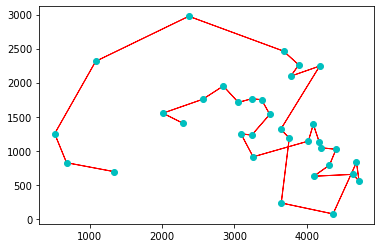

In [ ]:
# Gráfico
plot(solution.tour)